# RC Circuit Analysis

In lecture we saw that for an RC circuit, we have the magnitude and phase response:

$$
|H(\omega)| = \frac{1}{\sqrt{1 + (\omega RC)^2}}
$$

$$
\angle H(\omega) = \tan^{-1}(-\omega RC)
$$

Let's use some real values and predict the output of the circuit.

First import our standard packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1) Basic sinusoidal input

Recall that we have $\omega = 2\pi f$ where $f$ is in Hz.

Take $\text{R} = 1 \; k \Omega$ and $\text{C} = 330 \text{ nF}$

Now let's plug these values in and plot:

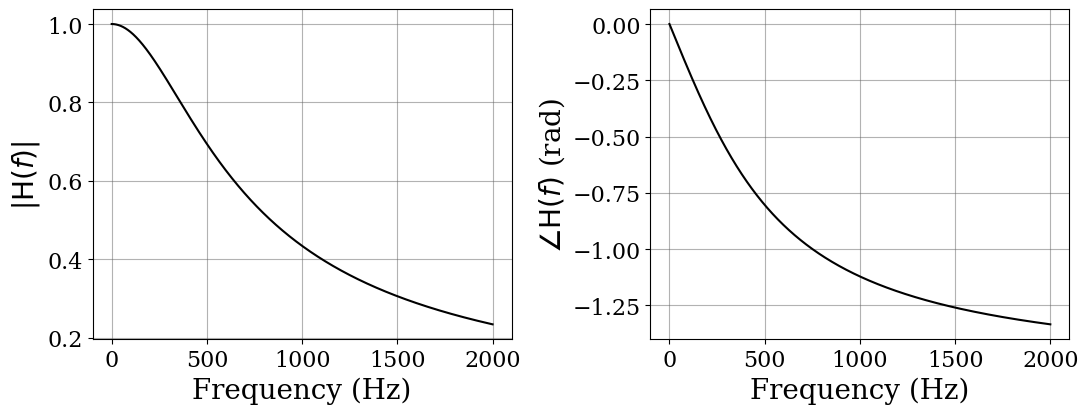

In [7]:
R = 1e3
C = 330e-9
freqs = np.linspace(0, 2e3, 10000)

mag = 1 / np.sqrt((1 + (2*np.pi*freqs*R*C)**2))
phase = np.arctan(-2*np.pi*freqs*R*C)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
for ax in axs:
    ax.set_xlabel("Frequency (Hz)")
axs[0].set_ylabel(r"$|\text{H}(f)|$")
axs[1].set_ylabel(r"$\angle \text{H} (f)$ (rad)")

axs[0].plot(freqs, mag)
axs[1].plot(freqs, phase)

fig.tight_layout()
fig.savefig("LowPassFilterResponse.pdf")

Now, let's define a sinusoidal signal and predict the output using our magnitude and phase response functions. Let's take a simple sinusoidal input signal:

$$
    x(t) = \cos (2\pi f t)
$$

And recall that our output is:

$$
    y(t) = |H(2\pi f)|\cos (2\pi f t + \angle H(2\pi f))
$$

Let's take $f = 5 \text{ kHz}$ and predict our output signal:

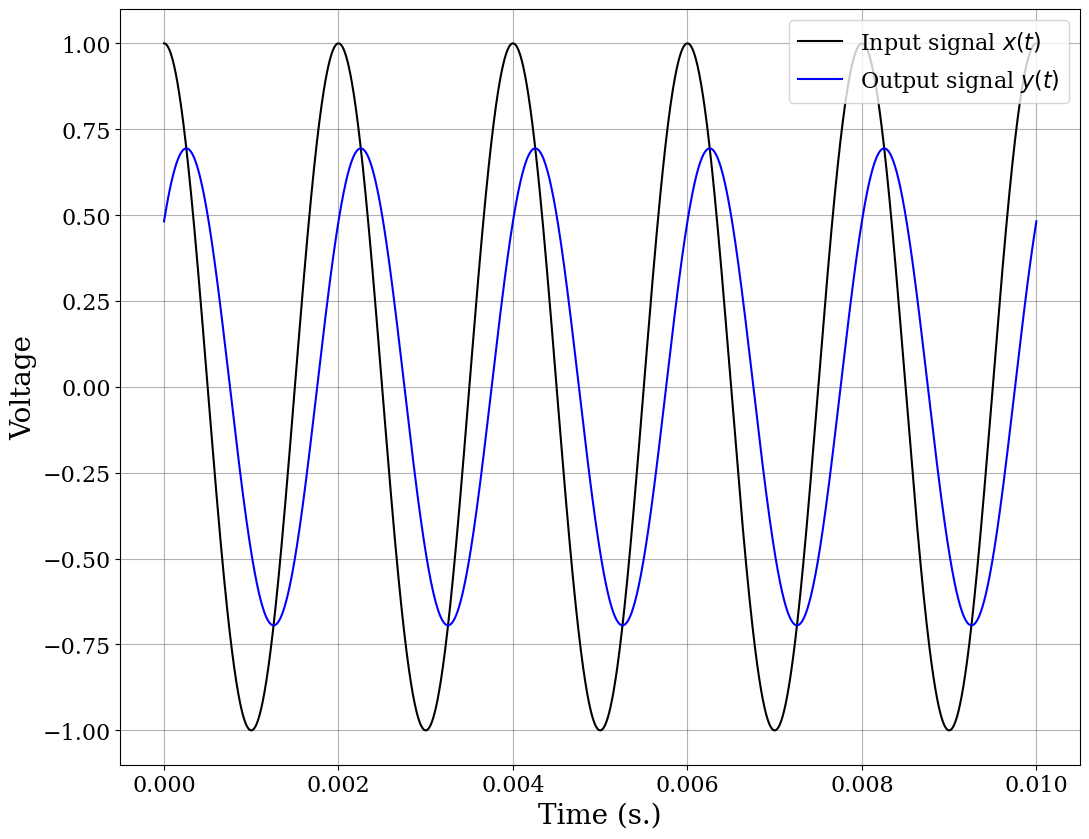

In [10]:
# - define the input signal - #
f = 500
t = np.linspace(0, 10e-3, 10000)
x = np.cos(2*np.pi*f*t)

# - compute the output signal - #
f_index = np.argmin(abs(freqs - f))
y = mag[f_index] * np.cos((2*np.pi*f*t) + phase[f_index])

fig, ax = plt.subplots()
ax.set(xlabel='Time (s.)', ylabel='Voltage')

ax.plot(t, x, label=r'Input signal $x(t)$')
ax.plot(t, y, color='blue', label=r'Output signal $y(t)$')
ax.legend(loc='upper right')

fig.tight_layout()
fig.savefig("LowPassIO_500Hz.pdf")

## Square wave input

A square wave is another periodic input, with sharp edges that are "square", as shown below:

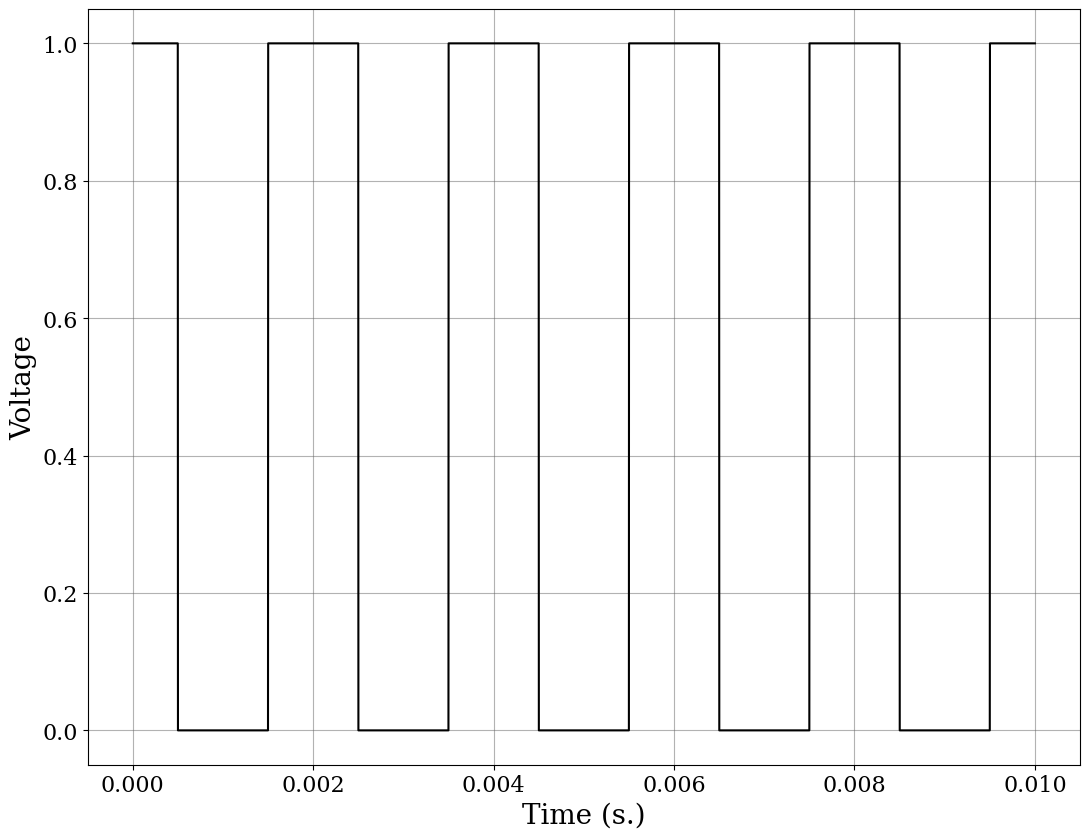

In [13]:
# - make the square wave signal - #
square_f = 500
t = np.linspace(0, 10e-3, 10000)
cos = np.cos(2*np.pi*square_f*t)
sign = np.sign(cos)
square = (sign + 1) / 2

# - plot the square wave - #
fig, ax = plt.subplots()
ax.set(xlabel='Time (s.)', ylabel='Voltage')

ax.plot(t, square)
fig.tight_layout()
fig.savefig('SquareWaveSignal.pdf')

We will soon see that this square wave signal $s(t)$ can be expressed as the following summation of sinusoids:

$$
s(t) = \frac{1}{2} + 2\sum_{n=1}^{\infty} \left[\frac{2\sin (n\pi/2)}{n\pi}\right] \cos(2\pi f n t)
$$

We can verify this statement here by truncating the summation and explicitly computing the sum:

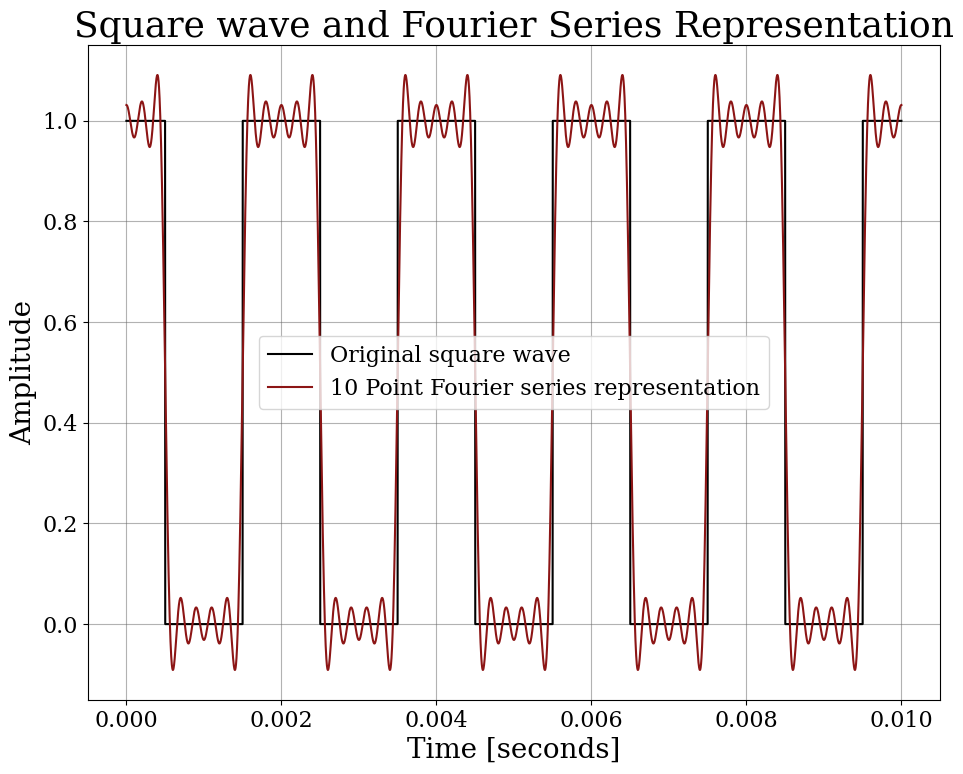

In [14]:
# - define a function to generate the fourier series - #
def get_fourier_representation(n, f, t):
    """ Generate the n point Fourier Series representation of a square wave signal.

    :param n: Number of coefficients to use in the Fourier Series representation.
    :param f: Fundamental frequency of the fourier series representation.
    :param t: Time vector.
    """
    sig = (1/2) * np.ones_like(t)
    for k in range(1, n):
        coef = np.sin(k * (np.pi / 2)) / (k * np.pi)
        cos = np.cos(k*2*np.pi*f*t)
        sig += 2 * coef * cos
    
    return sig

# - create an N term Fourier series - #
N = 10
fourier_series = get_fourier_representation(N, square_f, t)

fig, ax = plt.subplots()
ax.set(
    xlabel='Time [seconds]',
    ylabel='Amplitude',
    title='Square wave and Fourier Series Representation',
)

ax.plot(t, square, label='Original square wave')
ax.plot(t, fourier_series, label='%i Point Fourier series representation' % N)
ax.legend()

What would the output of our RC filter be to this square wave input? The answer is:

$$
y(t) = \frac{|H(0)|}{2} + 2\sum_{n=1}^{\infty} |H(2\pi f n)| \left[\frac{2\sin (n\pi/2)}{n\pi}\right] \cos(2\pi f n t + \angle H(2\pi f n))
$$

If $f = 500 \text{ Hz}$ as we used above, we get the output:

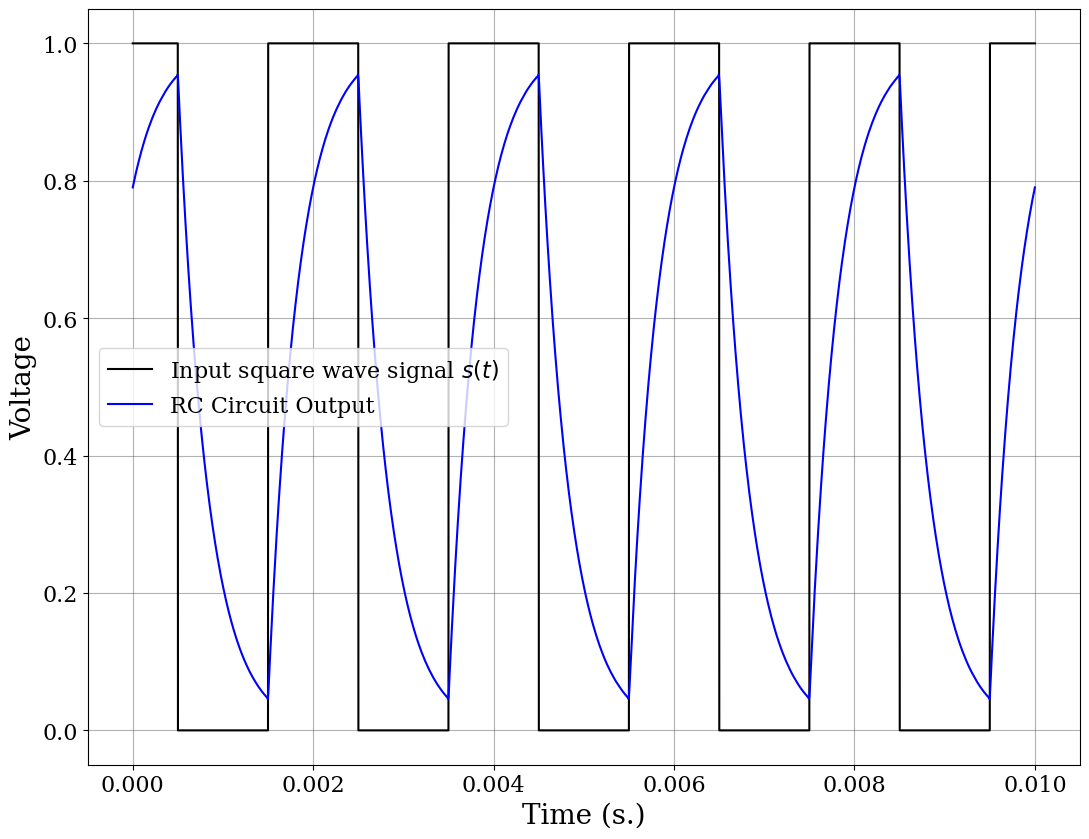

In [16]:
def get_square_wave_rc_output(n, f, t, R, C):
    """ Compute the output of an RC filter to a square wave input.

    :param n: Number of terms in the series summation.
    :param f: Fundamental frequency of the square wave.
    :param t: Time vector.
    :param R: Resistance of the circuit.
    :param C: Capacitance of the circuit.
    """
    # - compute the magnitude and phase response of the circuit - #
    high_freq = (n+1)*f
    freqs = np.linspace(0, high_freq, t.shape[0])
    mag = 1 / np.sqrt((1 + (2*np.pi*freqs*R*C)**2))
    phase = np.arctan(-2*np.pi*freqs*R*C)
    
    # - compute and return the circuit output - #
    sig = (1/2) * np.ones_like(t)
    for k in range(1, n):
        freq = k*f
        freq_index = np.argmin(abs(freqs - freq))
        coef = np.sin(k * (np.pi / 2)) / (k * np.pi)
        cos = np.cos(k*2*np.pi*f*t + phase[freq_index])
        sig += (2 * coef * cos) * mag[freq_index]
    
    return sig

rc_output = get_square_wave_rc_output(100, 500, t, R, C)

# - plot the square wave and the circuit output - #
fig, ax = plt.subplots()
ax.set(xlabel='Time (s.)', ylabel='Voltage')

ax.plot(t, square, label=r'Input square wave signal $s(t)$')
ax.plot(t, rc_output, color='blue', label='RC Circuit Output')
ax.legend()

fig.tight_layout()
fig.savefig('LowPassIO_Square.pdf')